In [1]:
from peaks import *

from hikyuu.interactive import *
import matplotlib.pyplot as plt


2026-04-29 18:11:52,360 [INFO] runing in interactive session [<module>] (c:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu\__init__.py:145) [hikyuu::hku_info]
2026-04-29 18:11:52,362 [INFO] running in jupyter [<module>] (c:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu\__init__.py:152) [hikyuu::hku_info]


2026-04-29 18:11:52.397 [HKU-I] - 插件路径: c:\Users\Zhi\AppData\Local\miniconda3\Lib\site-packages\hikyuu_plugin (StockManager.cpp:110)
2026-04-29 18:11:52.463 [HKU-I] - Using SQLITE3 BaseInfoDriver (BaseInfoDriver.cpp:56)
2026-04-29 18:11:52.528 [HKU-I] - 加载市场信息…… (StockManager.cpp:795)
2026-04-29 18:11:52.529 [HKU-I] - 加载证券类型信息…… (StockManager.cpp:812)
2026-04-29 18:11:52.530 [HKU-I] - 加载证券信息…… (StockManager.cpp:693)
2026-04-29 18:11:52.775 [HKU-I] - 加载权息数据…… (StockManager.cpp:829)
2026-04-29 18:11:53.335 [HKU-I] - 加载板块信息…… (StockManager.cpp:184)
2026-04-29 18:11:53.571 [HKU-I] - 加载K线数据…… (StockManager.cpp:188)
2026-04-29 18:11:53.572 [HKU-I] - 预加载 month K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:11:53.572 [HKU-I] - 预加载 day K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:11:53.573 [HKU-I] - 预加载 week K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:11:53.573 [HKU-I] - 预加载 year K线数据至缓存 (最大数量: 100000)! (StockManager.cpp:242)
2026-04-29 18:11:53.57

In [2]:
stock = sm['sh600089']  # 上证指数
query = Query(Datetime(202203010000), Datetime(202604010000), ktype = 'WEEK', recover_type = Query.BACKWARD) # 获取最近150个交易日
k =  stock.get_kdata(query)
# 方法1：绘制完整的阶段极点识别图
phase_lows, phase_highs= find_phase_peaks(k)


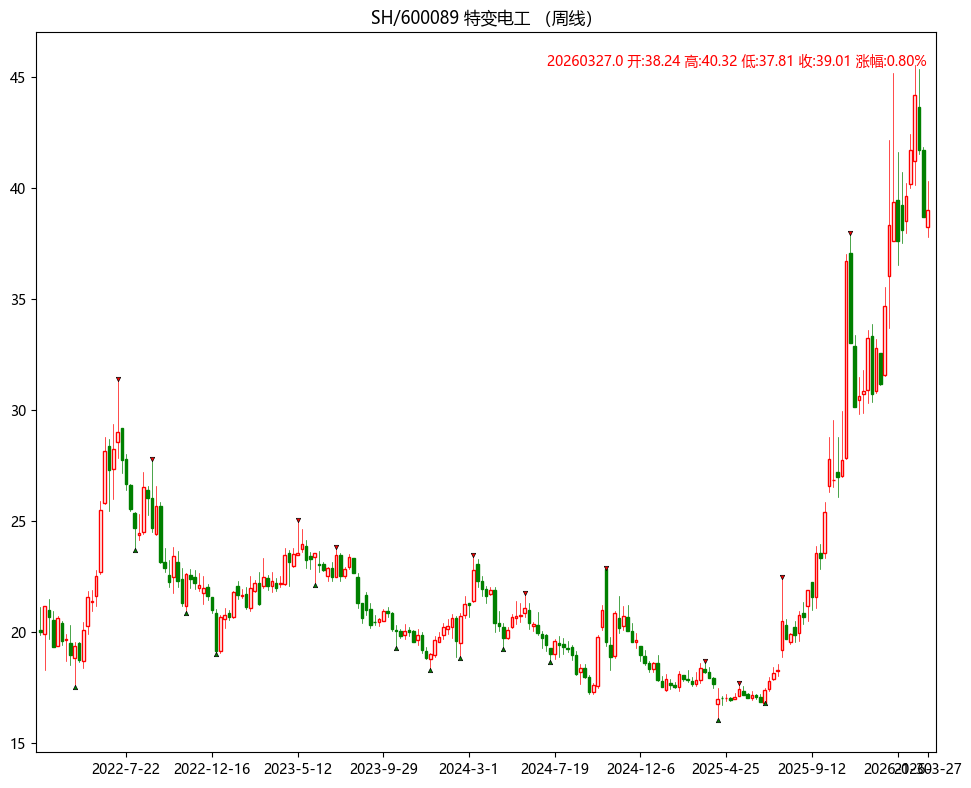

In [3]:
low_indices = [low['index'] for low in phase_lows]
low_prices_vals = [low['price'] for low in phase_lows]
high_indices = [high['index'] for high in phase_highs]
high_prices_vals = [high['price'] for high in phase_highs]

k.plot()
scatter_low = plt.scatter(low_indices, low_prices_vals, 
                                 color='green', marker='^', s=10,
                                 edgecolors='black', linewidths=0.5,
                                 label=f'阶段低点({len(phase_lows)}个)',
                                 zorder=5)
scatter_high = plt.scatter(high_indices, high_prices_vals, 
                                 color='red', marker='v', s=10,
                                 edgecolors='black', linewidths=0.5,
                                 label=f'阶段低点({len(phase_highs)}个)',
                                 zorder=5)